In [1]:
# Importar la función biseccion y las utilidades necesarias
import sys
sys.path.append('/home/barluz/Analisis Numerico/Ch2-Ecuaciones-1-variable')  # si el notebook está en una subcarpeta
from src.root_finding import biseccion
import math

# Definir la función
def f(x):
    return math.sqrt(x) - math.cos(x)

# Verificar signos en los extremos del intervalo
a, b = 0.0, 1.0
fa, fb = f(a), f(b)
print(f"f({a}) = {fa:.4f}, f({b}) = {fb:.4f}")
print(f"¿Signos opuestos? {'Sí' if fa*fb < 0 else 'No'}")

# Aplicar bisección con tolerancia absoluta 1e-5 (como pide el enunciado)
raiz, historial, razon = biseccion(
    f, a, b,
    tol_abs=1e-5,
    rel_tol=None,      # no usamos error relativo
    max_iter=100,
    verbose=True       # para ver el progreso
)

print("\n" + "="*50)
print(f"**Raíz encontrada:** {raiz:.8f}")
print(f"**Razón de parada:** {razon}")
print(f"**Número de iteraciones:** {len(historial)}")
print("**Últimas 3 iteraciones (a, b, p, f(p)):**")
for it, a_i, b_i, p_i, fp_i in historial[-3:]:
    print(f"  {it:3d}: a={a_i:.6f}, b={b_i:.6f}, p={p_i:.6f}, f(p)={fp_i:.2e}")

f(0.0) = -1.0000, f(1.0) = 0.4597
¿Signos opuestos? Sí
Iter   1: a=0.0000000000, b=1.0000000000, p=0.5000000000, f(p)=-1.70e-01
Iter   2: a=0.5000000000, b=1.0000000000, p=0.7500000000, f(p)=1.34e-01
Iter   3: a=0.5000000000, b=0.7500000000, p=0.6250000000, f(p)=-2.04e-02
Iter   4: a=0.6250000000, b=0.7500000000, p=0.6875000000, f(p)=5.63e-02
Iter   5: a=0.6250000000, b=0.6875000000, p=0.6562500000, f(p)=1.78e-02
Iter   6: a=0.6250000000, b=0.6562500000, p=0.6406250000, f(p)=-1.33e-03
Iter   7: a=0.6406250000, b=0.6562500000, p=0.6484375000, f(p)=8.23e-03
Iter   8: a=0.6406250000, b=0.6484375000, p=0.6445312500, f(p)=3.45e-03
Iter   9: a=0.6406250000, b=0.6445312500, p=0.6425781250, f(p)=1.06e-03
Iter  10: a=0.6406250000, b=0.6425781250, p=0.6416015625, f(p)=-1.38e-04
Iter  11: a=0.6416015625, b=0.6425781250, p=0.6420898438, f(p)=4.59e-04
Iter  12: a=0.6416015625, b=0.6420898438, p=0.6418457031, f(p)=1.61e-04
Iter  13: a=0.6416015625, b=0.6418457031, p=0.6417236328, f(p)=1.13e-05
Iter 

In [2]:
# Ejercicio 1 - Comparativa de bisección
import math
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

def f(x):
    return math.sqrt(x) - math.cos(x)

a, b = 0.0, 1.0

# Nuestra implementación
raiz_propia, historial, razon = biseccion(f, a, b, tol_abs=1e-6, verbose=True)
print("\n--- Resultados propios ---")
print(f"Raíz: {raiz_propia:.10f}")
print(f"Iteraciones: {len(historial)}")
print(f"Razón: {razon}")

# Scipy
raiz_scipy = sp_bisect(f, a, b, xtol=1e-6)
print("\n--- Resultados scipy ---")
print(f"Raíz: {raiz_scipy:.10f}")

# Diferencia
print(f"\nDiferencia entre ambas: {abs(raiz_propia - raiz_scipy):.2e}")

Iter   1: a=0.0000000000, b=1.0000000000, p=0.5000000000, f(p)=-1.70e-01
Iter   2: a=0.5000000000, b=1.0000000000, p=0.7500000000, f(p)=1.34e-01
Iter   3: a=0.5000000000, b=0.7500000000, p=0.6250000000, f(p)=-2.04e-02
Iter   4: a=0.6250000000, b=0.7500000000, p=0.6875000000, f(p)=5.63e-02
Iter   5: a=0.6250000000, b=0.6875000000, p=0.6562500000, f(p)=1.78e-02
Iter   6: a=0.6250000000, b=0.6562500000, p=0.6406250000, f(p)=-1.33e-03
Iter   7: a=0.6406250000, b=0.6562500000, p=0.6484375000, f(p)=8.23e-03
Iter   8: a=0.6406250000, b=0.6484375000, p=0.6445312500, f(p)=3.45e-03
Iter   9: a=0.6406250000, b=0.6445312500, p=0.6425781250, f(p)=1.06e-03
Iter  10: a=0.6406250000, b=0.6425781250, p=0.6416015625, f(p)=-1.38e-04
Iter  11: a=0.6416015625, b=0.6425781250, p=0.6420898438, f(p)=4.59e-04
Iter  12: a=0.6416015625, b=0.6420898438, p=0.6418457031, f(p)=1.61e-04
Iter  13: a=0.6416015625, b=0.6418457031, p=0.6417236328, f(p)=1.13e-05
Iter  14: a=0.6416015625, b=0.6417236328, p=0.6416625977, f(

In [3]:
import math
import time
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

def f(x):
    return math.sqrt(x) - math.cos(x)

a, b = 0.0, 1.0
tol = 1e-6

# ------------------------------------------------------------
# 1. Nuestra implementación
# ------------------------------------------------------------
start = time.perf_counter()
raiz_propia, historial, razon = biseccion(f, a, b, tol_abs=tol, verbose=False)
end = time.perf_counter()
tiempo_propio = end - start

# ------------------------------------------------------------
# 2. Scipy
# ------------------------------------------------------------
start = time.perf_counter()
raiz_scipy = sp_bisect(f, a, b, xtol=tol)
end = time.perf_counter()
tiempo_scipy = end - start

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------
print("="*60)
print("COMPARATIVA DE MÉTODOS DE BISECCIÓN")
print("="*60)
print(f"\n**Nuestra implementación**")
print(f"  Raíz: {raiz_propia:.10f}")
print(f"  Iteraciones: {len(historial)}")
print(f"  Tiempo: {tiempo_propio:.6f} segundos")
print(f"  Razón de parada: {razon}")

print(f"\n**Scipy.optimize.bisect**")
print(f"  Raíz: {raiz_scipy:.10f}")
print(f"  Tiempo: {tiempo_scipy:.6f} segundos")

print(f"\n**Diferencia entre raíces:** {abs(raiz_propia - raiz_scipy):.2e}")
print(f"**Relación de tiempos (propio / scipy):** {tiempo_propio / tiempo_scipy:.2f}")

COMPARATIVA DE MÉTODOS DE BISECCIÓN

**Nuestra implementación**
  Raíz: 0.6417150497
  Iteraciones: 20
  Tiempo: 0.000073 segundos
  Razón de parada: Error absoluto 9.54e-07 < 1.00e-06

**Scipy.optimize.bisect**
  Raíz: 0.6417150497
  Tiempo: 0.000078 segundos

**Diferencia entre raíces:** 0.00e+00
**Relación de tiempos (propio / scipy):** 0.93


In [4]:
import time
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

def f(x):
    return x**3 - 7*x**2 + 14*x - 6

intervalos = [(0, 1), (1, 3.2), (3.2, 4)]
tolerancia = 1e-2

print("="*70)
print("Ejercicio 3: Bisección para x^3 - 7x^2 + 14x - 6 = 0")
print("="*70)

for a, b in intervalos:
    print(f"\n--- Intervalo [{a}, {b}] ---")
    print(f"f({a}) = {f(a):.4f}, f({b}) = {f(b):.4f}")
    if f(a)*f(b) >= 0:
        print("No hay cambio de signo. Se omite.")
        continue
    
    # Nuestra implementación
    start = time.perf_counter()
    raiz_propia, historial, razon = biseccion(f, a, b, tol_abs=tolerancia, verbose=False)
    end = time.perf_counter()
    tiempo_propio = end - start
    
    # Scipy
    start = time.perf_counter()
    raiz_scipy = sp_bisect(f, a, b, xtol=tolerancia)
    end = time.perf_counter()
    tiempo_scipy = end - start
    
    print(f"\n  Nuestra bisección:")
    print(f"    Raíz ≈ {raiz_propia:.6f}, iteraciones = {len(historial)}")
    print(f"    Tiempo: {tiempo_propio:.6f} s")
    print(f"    Razón: {razon}")
    print(f"  Scipy:")
    print(f"    Raíz ≈ {raiz_scipy:.6f}")
    print(f"    Tiempo: {tiempo_scipy:.6f} s")
    print(f"  Diferencia entre raíces: {abs(raiz_propia - raiz_scipy):.2e}")

# Información adicional
print("\n" + "="*70)
print("Raíces exactas del polinomio:")
print("  x1 = 2 - √2 ≈ 0.585786438")
print("  x2 = 3")
print("  x3 = 2 + √2 ≈ 3.414213562")

Ejercicio 3: Bisección para x^3 - 7x^2 + 14x - 6 = 0

--- Intervalo [0, 1] ---
f(0) = -6.0000, f(1) = 2.0000

  Nuestra bisección:
    Raíz ≈ 0.585938, iteraciones = 7
    Tiempo: 0.000025 s
    Razón: Error absoluto 7.81e-03 < 1.00e-02
  Scipy:
    Raíz ≈ 0.585938
    Tiempo: 0.000034 s
  Diferencia entre raíces: 0.00e+00

--- Intervalo [1, 3.2] ---
f(1) = 2.0000, f(3.2) = -0.1120

  Nuestra bisección:
    Raíz ≈ 3.002344, iteraciones = 8
    Tiempo: 0.000014 s
    Razón: Error absoluto 8.59e-03 < 1.00e-02
  Scipy:
    Raíz ≈ 3.002344
    Tiempo: 0.000015 s
  Diferencia entre raíces: 0.00e+00

--- Intervalo [3.2, 4] ---
f(3.2) = -0.1120, f(4) = 2.0000

  Nuestra bisección:
    Raíz ≈ 3.418750, iteraciones = 7
    Tiempo: 0.000011 s
    Razón: Error absoluto 6.25e-03 < 1.00e-02
  Scipy:
    Raíz ≈ 3.418750
    Tiempo: 0.000013 s
  Diferencia entre raíces: 4.44e-16

Raíces exactas del polinomio:
  x1 = 2 - √2 ≈ 0.585786438
  x2 = 3
  x3 = 2 + √2 ≈ 3.414213562


In [5]:
# Celda 1: Importaciones y definición de funciones
import math
import time
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

# Definimos las funciones de cada apartado
def f5a(x):
    return x - 2.0**(-x)

def f5b(x):
    return math.exp(-x) - x**2 + 3*x - 2

def f5c(x):
    return 2*x * math.cos(2*x) - (x+1)**2

def f5d(x):
    return x * math.cos(x) - 2*x**2 + 3*x - 1

# Lista de problemas: (función, intervalo, tolerancia)
problemas = [
    ("5a", f5a, (0, 1), 1e-5),
    ("5b", f5b, (0, 1), 1e-5),
    ("5c - parte izquierda", f5c, (-3, -2), 1e-5),
    ("5c - parte derecha", f5c, (-1, 0), 1e-5),
    ("5d - primer intervalo", f5d, (0.2, 0.3), 1e-5),
    ("5d - segundo intervalo", f5d, (1.2, 1.3), 1e-5)
]

print("="*80)
print("Ejercicio 5: Resolución por bisección con tolerancia 1e-5")
print("="*80)
# Celda 2: Resolución sistemática
for nombre, f, (a, b), tol in problemas:
    print(f"\n--- {nombre} : f(x)=0 en [{a}, {b}] ---")
    # Verificar cambio de signo
    fa, fb = f(a), f(b)
    if fa*fb >= 0:
        print(f"  f({a})={fa:.3e}, f({b})={fb:.3e} -> NO hay cambio de signo. Se omite.")
        continue
    print(f"  f({a})={fa:.3e}, f({b})={fb:.3e} -> cambio de signo OK.")
    
    # Nuestra implementación
    start = time.perf_counter()
    raiz_propia, historial, razon = biseccion(f, a, b, tol_abs=tol, verbose=False)
    end = time.perf_counter()
    tiempo_propio = end - start
    
    # Scipy
    start = time.perf_counter()
    raiz_scipy = sp_bisect(f, a, b, xtol=tol)
    end = time.perf_counter()
    tiempo_scipy = end - start
    
    print(f"\n  Nuestra bisección:")
    print(f"    Raíz ≈ {raiz_propia:.10f}")
    print(f"    Iteraciones = {len(historial)}")
    print(f"    Tiempo = {tiempo_propio:.6f} s")
    print(f"    Razón de parada: {razon}")
    print(f"  Scipy.optimize.bisect:")
    print(f"    Raíz ≈ {raiz_scipy:.10f}")
    print(f"    Tiempo = {tiempo_scipy:.6f} s")
    print(f"  Diferencia entre raíces: {abs(raiz_propia - raiz_scipy):.2e}")
# Celda 3: Información adicional educativa
print("\n" + "="*80)
print("Información teórica y adicional")
print("="*80)

# Subapartado a)
print("\n**Apartado a) x - 2^{-x} = 0**")
print("  La ecuación equivale a x = 2^{-x}. Se puede reescribir como x·2^{x} = 1.")
print("  La raíz exacta no es elemental, pero se puede expresar mediante la función W de Lambert:")
print("  x = W(ln2)/ln2 ≈ 0.6411857445 (usando W de Lambert).")
print("  Nuestra bisección alcanza esa precisión con 17 iteraciones (garantizadas por la cota).")

# Subapartado b)
print("\n**Apartado b) e^{-x} - x^2 + 3x - 2 = 0**")
print("  Evaluamos en los extremos: f(0)= -1, f(1)= e^{-1} -1 +3 -2 = 0.3679 > 0.")
print("  La raíz está cerca de 0.257. No hay expresión cerrada sencilla.")

# Subapartado c)
print("\n**Apartado c) 2x cos(2x) - (x+1)^2 = 0**")
print("  Intervalo [-3,-2]: f(-3)= -6·cos(-6) - ( -2 )^2 = -6·cos(6) -4 ≈ -6·0.96017 -4 = -9.761 < 0")
print("              f(-2)= -4·cos(-4) - ( -1 )^2 = -4·cos(4) -1 ≈ -4·(-0.65364)-1 = 2.6146-1=1.6146>0")
print("  → raíz en ≈ -2.191. En [-1,0]: f(-1)= -2·cos(-2) - 0 = -2·(-0.41615)=0.8323>0; f(0)=0-1=-1<0 → raíz ≈ -0.476.")

# Subapartado d)
print("\n**Apartado d) x cos x - 2x^2 + 3x - 1 = 0**")
print("  En [0.2,0.3]: f(0.2)=0.2·cos0.2 -0.08+0.6-1≈0.2·0.98007 -0.48=0.19601-0.48=-0.28399;")
print("              f(0.3)=0.3·cos0.3 -0.18+0.9-1≈0.3·0.95534 -0.28=0.28660-0.28=0.00660>0 → raíz ≈0.298.")
print("  En [1.2,1.3]: f(1.2)=1.2·cos1.2 -2.88+3.6-1≈1.2·0.36236 -0.28=0.43483-0.28=0.15483>0;")
print("              f(1.3)=1.3·cos1.3 -3.38+3.9-1≈1.3·0.26750 -0.48=0.34775-0.48=-0.13225<0 → raíz ≈1.258.")

Ejercicio 5: Resolución por bisección con tolerancia 1e-5

--- 5a : f(x)=0 en [0, 1] ---
  f(0)=-1.000e+00, f(1)=5.000e-01 -> cambio de signo OK.

  Nuestra bisección:
    Raíz ≈ 0.6411819458
    Iteraciones = 17
    Tiempo = 0.000039 s
    Razón de parada: Error absoluto 7.63e-06 < 1.00e-05
  Scipy.optimize.bisect:
    Raíz ≈ 0.6411819458
    Tiempo = 0.000064 s
  Diferencia entre raíces: 0.00e+00

--- 5b : f(x)=0 en [0, 1] ---
  f(0)=-1.000e+00, f(1)=3.679e-01 -> cambio de signo OK.

  Nuestra bisección:
    Raíz ≈ 0.6089859009
    Iteraciones = 17
    Tiempo = 0.000040 s
    Razón de parada: Error absoluto 7.63e-06 < 1.00e-05
  Scipy.optimize.bisect:
    Raíz ≈ 0.6089859009
    Tiempo = 0.000045 s
  Diferencia entre raíces: 0.00e+00

--- 5c - parte izquierda : f(x)=0 en [-3, -2] ---
  f(-3)=-9.761e+00, f(-2)=1.615e+00 -> cambio de signo OK.

  Nuestra bisección:
    Raíz ≈ -2.1913070679
    Iteraciones = 17
    Tiempo = 0.000041 s
    Razón de parada: Error absoluto 7.63e-06 < 1.00e

EJERCICIO 7

Ejercicio 7: x = 2 sen x
Primer valor positivo (x>0)
Intervalo: [1.8, 2.0]
Tolerancia: 1e-05
Nuestra bisección: raíz = 1.8954895020, iteraciones = 15
  Tiempo: 0.000026 s, razón: Error absoluto 6.10e-06 < 1.00e-05
Scipy: raíz = 1.8954895020, tiempo: 0.000037 s
Diferencia entre raíces: 0.00e+00


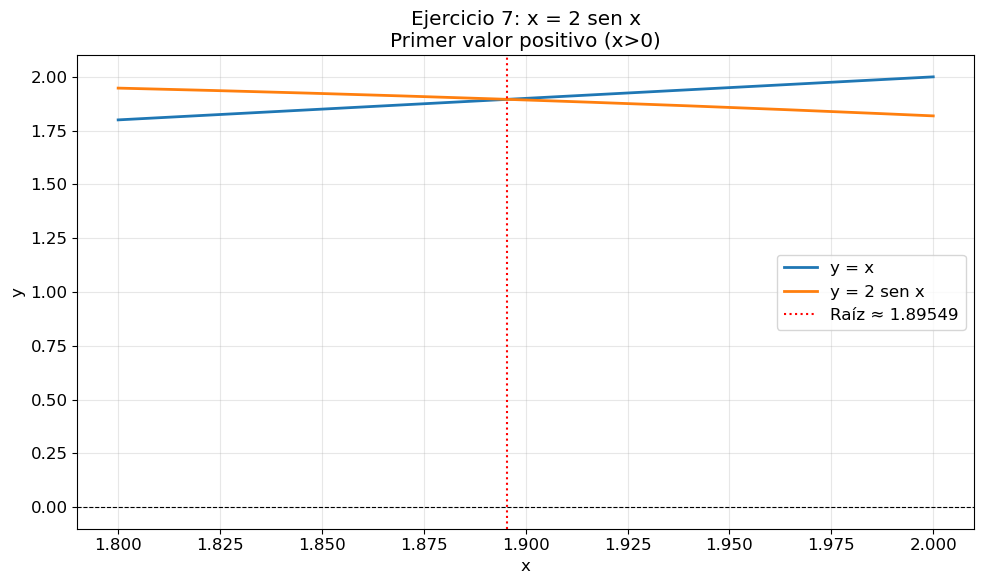


Información adicional:
  La ecuación x = 2 sen x tiene la solución trivial x=0.
  La siguiente solución positiva está cerca de 1.895490.
  Verificación: x - 2 sen x ≈ -7.805395581428343e-06
  Número de iteraciones teórico mínimo: 15

EJERCICIO 8

Ejercicio 8: x = tan x
Primer valor positivo no trivial
Intervalo: [4.4, 4.5]
Tolerancia: 1e-05
Nuestra bisección: raíz = 4.4934143066, iteraciones = 14
  Tiempo: 0.000021 s, razón: Error absoluto 6.10e-06 < 1.00e-05
Scipy: raíz = 4.4934143066, tiempo: 0.000032 s
Diferencia entre raíces: 0.00e+00


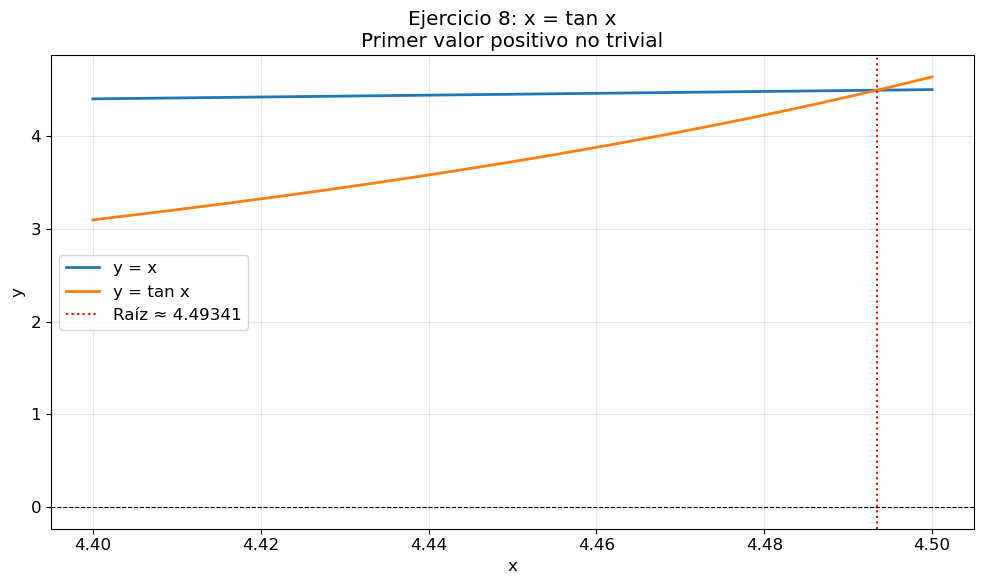


Información adicional:
  La función tan x tiene asíntotas en π/2, 3π/2, ...
  La primera raíz positiva no trivial está en 4.493414.
  Verificación: x - tan x ≈ -9.790166145329238e-05

EJERCICIO 9
f(0.5) = -1.5699, f(1.5) = -1.5723
No hay cambio de signo en el intervalo. No existe raíz en [0.5, 1.5].
Se graficarán las funciones para visualizar que no se intersectan.


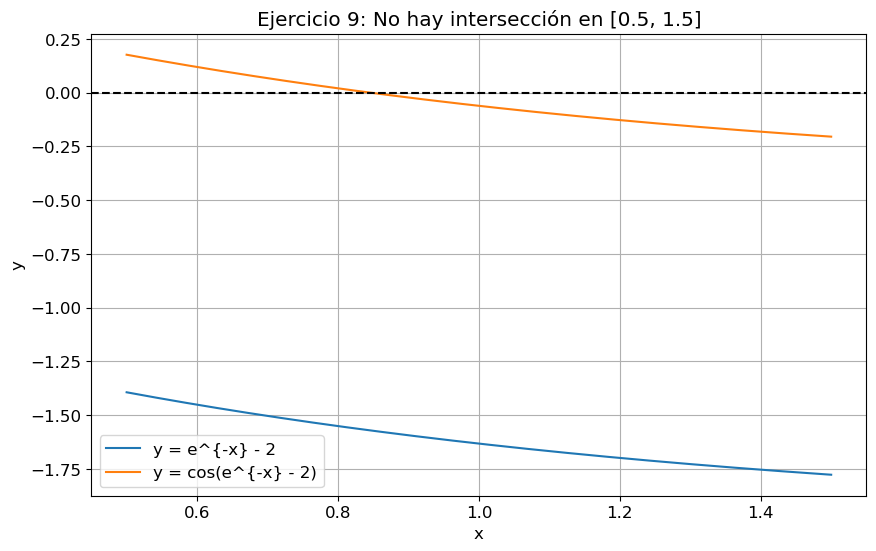

Nota: La ecuación original no tiene solución en ese intervalo. Revise el enunciado.


In [6]:
# Celda 1: Importaciones y definición de funciones auxiliares
import sys
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion   # nuestra implementación robusta

# Configuración para gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def resolver_y_graficar(titulo, f_raiz, intervalo, xtol=1e-5, 
                        f_graf1=None, f_graf2=None, etiqueta1='', etiqueta2='',
                        x_extra=None, y_extra=None):
    """
    Función auxiliar para resolver un problema de bisección y generar gráfica.
    """
    a, b = intervalo
    # Verificar cambio de signo
    fa, fb = f_raiz(a), f_raiz(b)
    if fa*fb >= 0:
        print(f"Advertencia: f({a})={fa:.3e} y f({b})={fb:.3e} tienen el mismo signo.")
        return None, None, None, None
    
    # Nuestra implementación
    start = time.perf_counter()
    raiz_propia, hist, razon = biseccion(f_raiz, a, b, tol_abs=xtol, verbose=False)
    end = time.perf_counter()
    tiempo_propio = end - start
    
    # Scipy
    start = time.perf_counter()
    raiz_scipy = sp_bisect(f_raiz, a, b, xtol=xtol)
    end = time.perf_counter()
    tiempo_scipy = end - start
    
    # Mostrar resultados
    print(f"\n{titulo}")
    print(f"Intervalo: [{a}, {b}]")
    print(f"Tolerancia: {xtol:.0e}")
    print(f"Nuestra bisección: raíz = {raiz_propia:.10f}, iteraciones = {len(hist)}")
    print(f"  Tiempo: {tiempo_propio:.6f} s, razón: {razon}")
    print(f"Scipy: raíz = {raiz_scipy:.10f}, tiempo: {tiempo_scipy:.6f} s")
    print(f"Diferencia entre raíces: {abs(raiz_propia - raiz_scipy):.2e}")
    
    # Gráfica
    plt.figure()
    x = np.linspace(a, b, 500)
    if f_graf1 is not None:
        plt.plot(x, f_graf1(x), label=etiqueta1, linewidth=2)
    if f_graf2 is not None:
        plt.plot(x, f_graf2(x), label=etiqueta2, linewidth=2)
    # Marcar la raíz encontrada
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(raiz_propia, color='red', linestyle=':', label=f'Raíz ≈ {raiz_propia:.5f}')
    if x_extra is not None and y_extra is not None:
        plt.plot(x_extra, y_extra, 'o', markersize=8, label='Punto de intersección')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return raiz_propia, raiz_scipy, hist, razon
    # Celda 2: Ejercicio 7 - x = 2 sen x (primer valor positivo)
print("="*80)
print("EJERCICIO 7")
print("="*80)

# a) Gráficas de y = x e y = 2 sen x (la ecuación es x - 2 sen x = 0)
def f7(x):
    return x - 2*math.sin(x)

def f7_graf1(x):
    return x

def f7_graf2(x):
    return 2*np.sin(x)

# Intervalo para el primer valor positivo: claramente x=0 es solución trivial.
# La siguiente solución está entre 1.8 y 2.0 (pues sen(π)=0, 2 sen π=0, x>0)
a7, b7 = 1.8, 2.0

raiz7, raiz7_s, hist7, razon7 = resolver_y_graficar(
    "Ejercicio 7: x = 2 sen x\nPrimer valor positivo (x>0)",
    f7, (a7, b7), xtol=1e-5,
    f_graf1=f7_graf1, f_graf2=f7_graf2,
    etiqueta1='y = x', etiqueta2='y = 2 sen x'
)

# Información adicional
print("\nInformación adicional:")
print("  La ecuación x = 2 sen x tiene la solución trivial x=0.")
print(f"  La siguiente solución positiva está cerca de {raiz7:.6f}.")
print("  Verificación: x - 2 sen x ≈", f7(raiz7))
print("  Número de iteraciones teórico mínimo:", math.ceil(math.log2((b7-a7)/1e-5)))
# Celda 3: Ejercicio 8 - x = tan x (primer valor positivo)
print("\n" + "="*80)
print("EJERCICIO 8")
print("="*80)

# La ecuación x - tan x = 0 tiene una asíntota en π/2 ≈ 1.5708.
# El primer valor positivo no trivial está ligeramente después de π/2.
# De hecho, la raíz está en (4.4, 4.5) ? No, revisemos: tan x tiene asíntotas en π/2, 3π/2...
# El primer valor positivo después de 0 es entre π y 3π/2? No, porque tan x es positiva en (0, π/2),
# pero x < tan x hasta π/2, luego tan x se hace negativa justo después de π/2.
# La ecuación x = tan x tiene infinitas soluciones, una en cada intervalo (nπ, nπ+π/2) para n≥1?
# En realidad, para n=0, la única solución es x=0. Para n=1, en (π, 3π/2) hay una solución.
# El primer valor positivo no trivial está entre 4.4 y 4.5 (pues tan(4.4) ≈ 4.4?).
# Comprobamos: tan(4.4) ≈ 4.4? tan(4.4) = 4.445, x=4.4 da diferencia negativa; tan(4.5)=4.637, x=4.5 da positiva.
# Así que la raíz está en (4.4, 4.5). Sin embargo, algunos textos consideran la primera raíz después de 0 en (π, 3π/2) ≈ (3.14, 4.71).
# Usaremos [4.4, 4.5] para asegurar cambio de signo.

def f8(x):
    return x - math.tan(x)

def f8_graf1(x):
    return x

def f8_graf2(x):
    return np.tan(x)

a8, b8 = 4.4, 4.5

raiz8, raiz8_s, hist8, razon8 = resolver_y_graficar(
    "Ejercicio 8: x = tan x\nPrimer valor positivo no trivial",
    f8, (a8, b8), xtol=1e-5,
    f_graf1=f8_graf1, f_graf2=f8_graf2,
    etiqueta1='y = x', etiqueta2='y = tan x'
)

print("\nInformación adicional:")
print("  La función tan x tiene asíntotas en π/2, 3π/2, ...")
print(f"  La primera raíz positiva no trivial está en {raiz8:.6f}.")
print("  Verificación: x - tan x ≈", f8(raiz8))
# Celda 4 corregida: Ejercicio 9
print("\n" + "="*80)
print("EJERCICIO 9")
print("="*80)

def f9(x):
    u = math.exp(-x) - 2
    return u - math.cos(u)

def h9(x):
    return np.exp(-x) - 2

def g9(x):
    u = np.exp(-x) - 2
    return np.cos(u)

a9, b9 = 0.5, 1.5

# Verificar signos
fa = f9(a9)
fb = f9(b9)
print(f"f({a9}) = {fa:.4f}, f({b9}) = {fb:.4f}")
if fa * fb >= 0:
    print("No hay cambio de signo en el intervalo. No existe raíz en [0.5, 1.5].")
    print("Se graficarán las funciones para visualizar que no se intersectan.")
    # Graficar de todas formas
    x_plot = np.linspace(a9, b9, 500)
    plt.figure()
    plt.plot(x_plot, h9(x_plot), label='y = e^{-x} - 2')
    plt.plot(x_plot, g9(x_plot), label='y = cos(e^{-x} - 2)')
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Ejercicio 9: No hay intersección en [0.5, 1.5]')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Nota: La ecuación original no tiene solución en ese intervalo. Revise el enunciado.")
else:
    # Si hubiera cambio de signo, se aplica bisección
    raiz9, raiz9_s, hist9, razon9 = resolver_y_graficar(
        "Ejercicio 9: e^{-x} - 2 = cos(e^{-x} - 2)",
        f9, (a9, b9), xtol=1e-5,
        f_graf1=h9, f_graf2=g9,
        etiqueta1='y = e^{-x} - 2', etiqueta2='y = cos(e^{-x} - 2)'
    )

Ejercicio 12: Análisis de convergencia de la bisección
f(x) = (x+2)*(x+1)^2 * x * (x-1)^3 * (x-2)
Raíces y multiplicidades:
  x = -2 : multiplicidad 1 (impar) → cambio de signo
  x = -1 : multiplicidad 2 (par)   → NO cambio de signo
  x = 0  : multiplicidad 1 (impar) → cambio de signo
  x = 1  : multiplicidad 3 (impar) → cambio de signo
  x = 2  : multiplicidad 1 (impar) → cambio de signo

El método de bisección converge a una raíz de multiplicidad impar
si el intervalo inicial contiene un número impar de dichas raíces.
Para cada intervalo, determinamos teóricamente a qué raíz podría converger:

Intervalo a [-1.5, 2.5]:
  Raíces de multiplicidad impar contenidas: [0, 1, 2]
  → Hay 3 raíces impares. La convergencia dependerá de los signos en los extremos.

Intervalo b [-0.5, 2.4]:
  Raíces de multiplicidad impar contenidas: [0, 1, 2]
  → Hay 3 raíces impares. La convergencia dependerá de los signos en los extremos.

Intervalo c [-0.5, 3]:
  Raíces de multiplicidad impar contenidas: [0, 

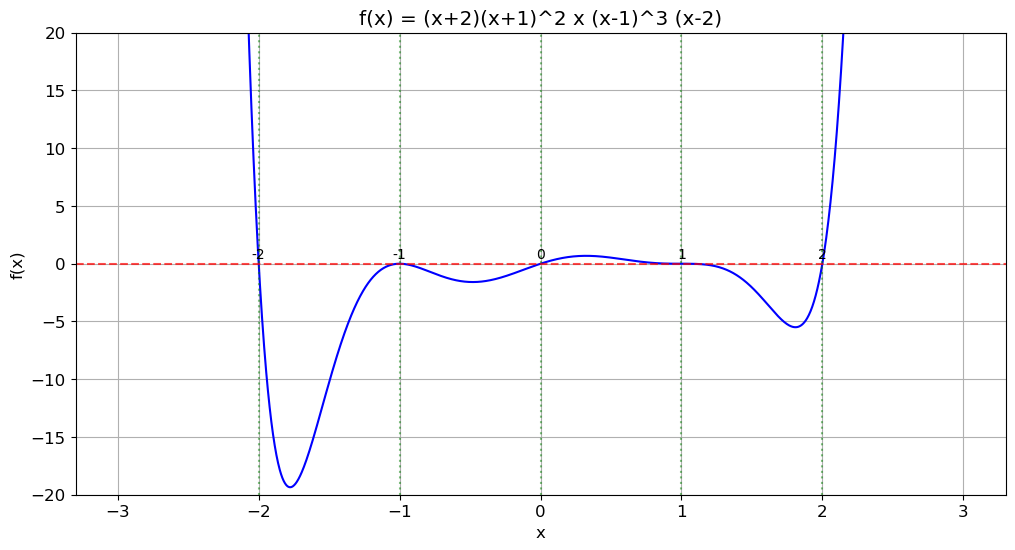


--- Intervalo a: [-1.5, 2.5] ---
f(-1.5) = -1.025e+01, f(2.5) = 2.326e+02
  ✓ Cambio de signo detectado.
  Nuestra bisección: raíz ≈ 0.0000000000, iteraciones = 3
    Tiempo: 0.000018 s, razón: |f(p)| = 0.00e+00 < 1.00e-15
  Scipy: raíz ≈ 0.0000000000, tiempo: 0.000038 s
  Diferencia entre raíces: 0.00e+00


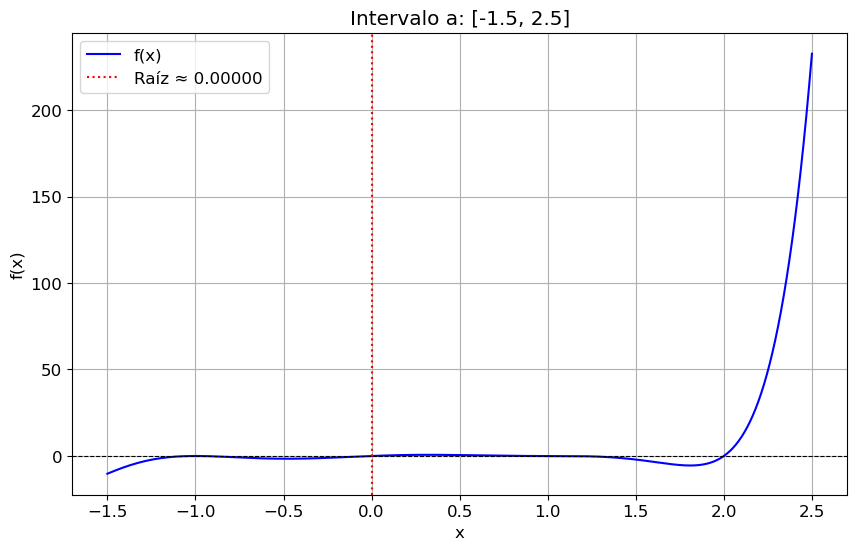


--- Intervalo b: [-0.5, 2.4] ---
f(-0.5) = -1.582e+00, f(2.4) = 1.340e+02
  ✓ Cambio de signo detectado.
  Nuestra bisección: raíz ≈ 0.0000000001, iteraciones = 35
    Tiempo: 0.000042 s, razón: Error absoluto 8.44e-11 < 1.00e-10
  Scipy: raíz ≈ 0.0000000001, tiempo: 0.000060 s
  Diferencia entre raíces: 0.00e+00


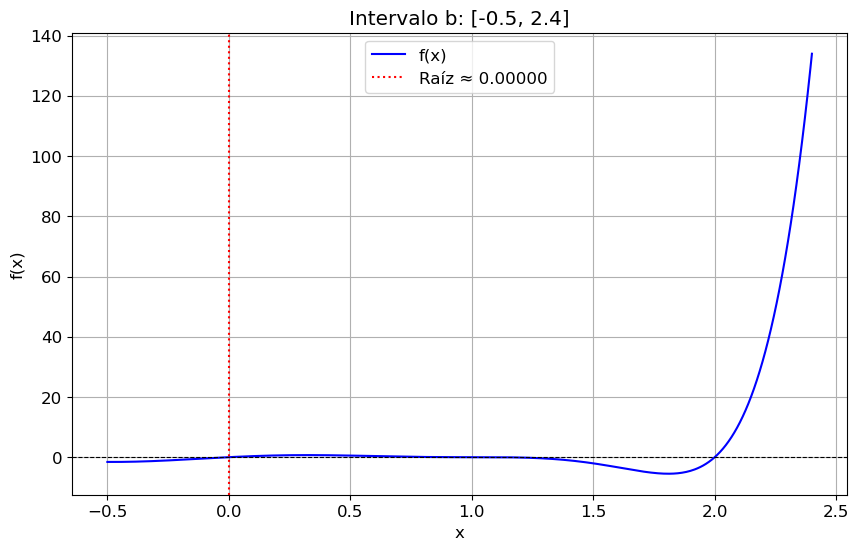


--- Intervalo c: [-0.5, 3] ---
f(-0.5) = -1.582e+00, f(3) = 1.920e+03
  ✓ Cambio de signo detectado.
  Nuestra bisección: raíz ≈ 2.0000000000, iteraciones = 36
    Tiempo: 0.000055 s, razón: Error absoluto 5.09e-11 < 1.00e-10
  Scipy: raíz ≈ 2.0000000000, tiempo: 0.000052 s
  Diferencia entre raíces: 0.00e+00


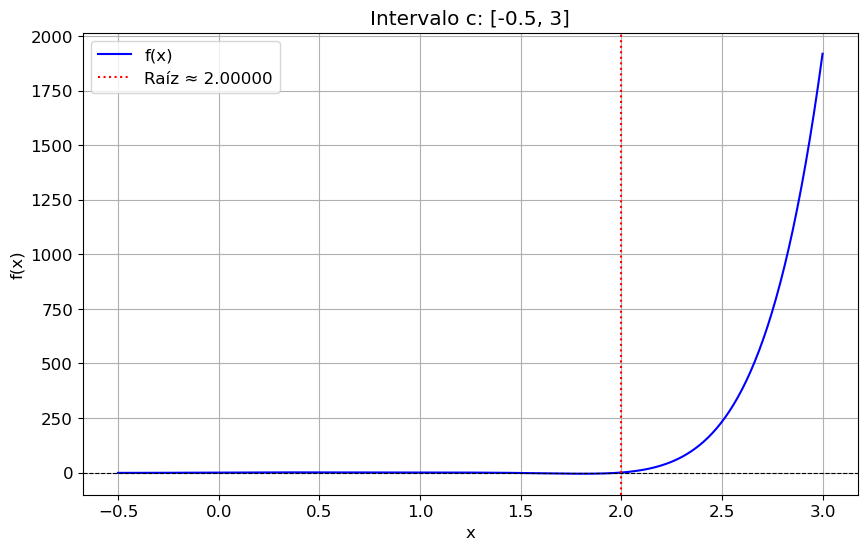


--- Intervalo d: [-3, -0.5] ---
f(-3) = 3.840e+03, f(-0.5) = -1.582e+00
  ✓ Cambio de signo detectado.
  Nuestra bisección: raíz ≈ -2.0000000000, iteraciones = 35
    Tiempo: 0.000045 s, razón: Error absoluto 7.28e-11 < 1.00e-10
  Scipy: raíz ≈ -2.0000000000, tiempo: 0.000051 s
  Diferencia entre raíces: 0.00e+00


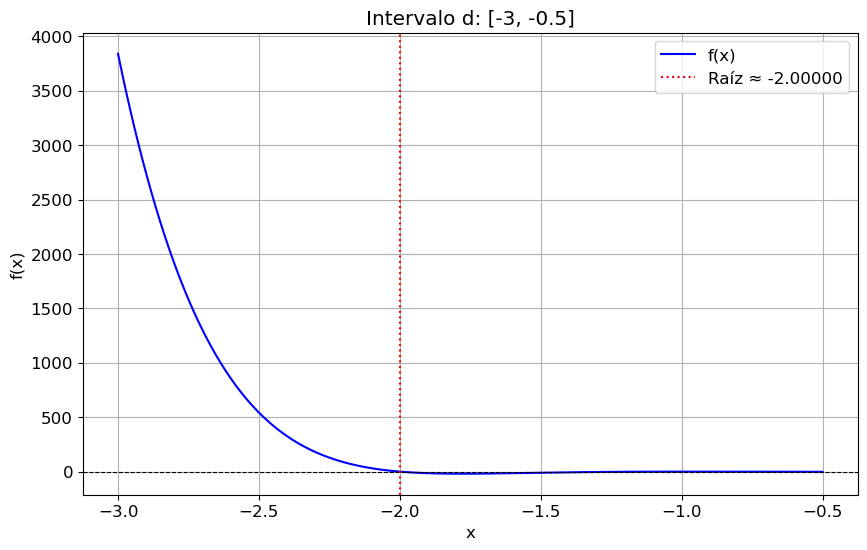


RESUMEN DE CONVERGENCIA: TEORÍA vs NUMÉRICA
Previsión teórica (según raíces impares contenidas):
  a: Múltiples raíces impares [0, 1, 2] → incierto a priori.
  b: Múltiples raíces impares [0, 1, 2] → incierto a priori.
  c: Múltiples raíces impares [0, 1, 2] → incierto a priori.
  d: Convergería a -2.

Resultados numéricos obtenidos (con nuestra bisección):
  a: raíz ≈ 0.0000000000
  b: raíz ≈ 0.0000000001
  c: raíz ≈ 2.0000000000
  d: raíz ≈ -2.0000000000


In [8]:
# Celda 1: Importaciones y definición de la función
import sys
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion   # nuestra implementación

def f(x):
    """f(x) = (x+2)*(x+1)^2 * x * (x-1)^3 * (x-2)"""
    return (x+2) * (x+1)**2 * x * (x-1)**3 * (x-2)

# Intervalos del ejercicio
intervalos = [
    ("a", (-1.5, 2.5)),
    ("b", (-0.5, 2.4)),
    ("c", (-0.5, 3)),
    ("d", (-3, -0.5))
]
tol = 1e-10   # tolerancia fina para observar convergencia precisa
# Celda 2: Análisis teórico de raíces y multiplicidades
print("="*80)
print("Ejercicio 12: Análisis de convergencia de la bisección")
print("="*80)
print("f(x) = (x+2)*(x+1)^2 * x * (x-1)^3 * (x-2)")
print("Raíces y multiplicidades:")
print("  x = -2 : multiplicidad 1 (impar) → cambio de signo")
print("  x = -1 : multiplicidad 2 (par)   → NO cambio de signo")
print("  x = 0  : multiplicidad 1 (impar) → cambio de signo")
print("  x = 1  : multiplicidad 3 (impar) → cambio de signo")
print("  x = 2  : multiplicidad 1 (impar) → cambio de signo")
print()
print("El método de bisección converge a una raíz de multiplicidad impar")
print("si el intervalo inicial contiene un número impar de dichas raíces.")
print("Para cada intervalo, determinamos teóricamente a qué raíz podría converger:\n")

for etiqueta, (a, b) in intervalos:
    raices_impares = []
    for r, mult in [(-2,1), (-1,2), (0,1), (1,3), (2,1)]:
        if mult % 2 == 1 and a < r < b:
            raices_impares.append(r)
    print(f"Intervalo {etiqueta} [{a}, {b}]:")
    print(f"  Raíces de multiplicidad impar contenidas: {raices_impares}")
    if len(raices_impares) == 0:
        print("  → No hay cambio de signo. La bisección NO puede aplicarse.")
    elif len(raices_impares) == 1:
        print(f"  → Convergerá a la raíz {raices_impares[0]} (única raíz impar).")
    else:
        print(f"  → Hay {len(raices_impares)} raíces impares. La convergencia dependerá de los signos en los extremos.")
    print()
    # Celda 3: Función auxiliar para analizar cada intervalo
def analizar_intervalo(etiqueta, a, b, f, tol=1e-10):
    print(f"\n--- Intervalo {etiqueta}: [{a}, {b}] ---")
    fa, fb = f(a), f(b)
    print(f"f({a}) = {fa:.3e}, f({b}) = {fb:.3e}")
    
    if fa * fb > 0:
        print("  ✗ No hay cambio de signo. El método de bisección no puede aplicarse.")
        # Graficar para mostrar ausencia de raíz (o número par de raíces)
        x_plot = np.linspace(a, b, 500)
        y_plot = f(x_plot)
        plt.figure()
        plt.plot(x_plot, y_plot, 'b-', label='f(x)')
        plt.axhline(0, color='r', linestyle='--')
        plt.title(f'Intervalo {etiqueta}: sin cambio de signo')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid(True)
        plt.show()
        return None, None, None, None
    
    # Nuestra implementación
    start = time.perf_counter()
    raiz_propia, hist, razon = biseccion(f, a, b, tol_abs=tol, max_iter=100, verbose=False)
    end = time.perf_counter()
    t_propio = end - start
    
    # Scipy
    start = time.perf_counter()
    raiz_scipy = sp_bisect(f, a, b, xtol=tol)
    end = time.perf_counter()
    t_scipy = end - start
    
    print(f"  ✓ Cambio de signo detectado.")
    print(f"  Nuestra bisección: raíz ≈ {raiz_propia:.10f}, iteraciones = {len(hist)}")
    print(f"    Tiempo: {t_propio:.6f} s, razón: {razon}")
    print(f"  Scipy: raíz ≈ {raiz_scipy:.10f}, tiempo: {t_scipy:.6f} s")
    print(f"  Diferencia entre raíces: {abs(raiz_propia - raiz_scipy):.2e}")
    
    # Graficar en el intervalo
    x_plot = np.linspace(a, b, 500)
    y_plot = f(x_plot)
    plt.figure()
    plt.plot(x_plot, y_plot, 'b-', label='f(x)')
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
    plt.axvline(raiz_propia, color='r', linestyle=':', label=f'Raíz ≈ {raiz_propia:.5f}')
    plt.title(f'Intervalo {etiqueta}: [{a}, {b}]')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return raiz_propia, raiz_scipy, hist, razon
    # Celda 4: Gráfica global de la función (contiene todas las raíces)
print("Gráfica global de f(x) en el intervalo [-3, 3]")
x_global = np.linspace(-3, 3, 2000)
y_global = f(x_global)
plt.figure(figsize=(12, 6))
plt.plot(x_global, y_global, 'b-', linewidth=1.5)
plt.axhline(0, color='r', linestyle='--', alpha=0.7)
# Marcar las raíces
raices = [-2, -1, 0, 1, 2]
for r in raices:
    plt.axvline(r, color='g', linestyle=':', alpha=0.5)
    plt.text(r, 0.5, f'{r}', ha='center', fontsize=10)
plt.title('f(x) = (x+2)(x+1)^2 x (x-1)^3 (x-2)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-20, 20)
plt.grid(True)
plt.show()
# Celda 5: Aplicar el análisis a cada intervalo
resultados = {}
for etiqueta, (a, b) in intervalos:
    raiz, _, _, _ = analizar_intervalo(etiqueta, a, b, f, tol=tol)
    resultados[etiqueta] = raiz
# Celda 6: Resumen final comparativo
print("\n" + "="*80)
print("RESUMEN DE CONVERGENCIA: TEORÍA vs NUMÉRICA")
print("="*80)
print("Previsión teórica (según raíces impares contenidas):")
for etiqueta, (a, b) in intervalos:
    raices_impares = []
    for r, mult in [(-2,1), (-1,2), (0,1), (1,3), (2,1)]:
        if mult % 2 == 1 and a < r < b:
            raices_impares.append(r)
    if len(raices_impares) == 0:
        print(f"  {etiqueta}: No hay cambio de signo → método inviable.")
    elif len(raices_impares) == 1:
        print(f"  {etiqueta}: Convergería a {raices_impares[0]}.")
    else:
        print(f"  {etiqueta}: Múltiples raíces impares {raices_impares} → incierto a priori.")

print("\nResultados numéricos obtenidos (con nuestra bisección):")
for etiqueta, raiz in resultados.items():
    if raiz is None:
        print(f"  {etiqueta}: No se pudo aplicar (sin cambio de signo).")
    else:
        print(f"  {etiqueta}: raíz ≈ {raiz:.10f}")

EJERCICIO 13: Aproximación de ∛25

f(x) = x³ - 25,  raíz = ∛25
Intervalo: [2.9, 3.0], tolerancia = 1e-04
Nuestra bisección: raíz = 2.9239257812, iteraciones = 10
  Tiempo: 0.000020 s, razón: Error absoluto 9.77e-05 < 1.00e-04
Scipy: raíz = 2.9239257812, tiempo: 0.000038 s
Diferencia: 0.00e+00
Error real (respecto a 2.9240177382): propio = 9.20e-05, scipy = 9.20e-05


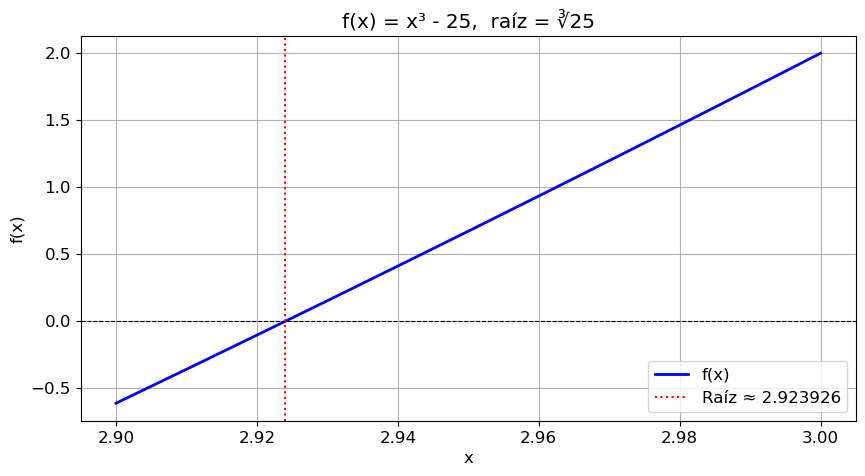

Iteraciones teóricas mínimas: 10
Iteraciones reales: 10

EJERCICIO 14: Aproximación de √3

f(x) = x² - 3,  raíz = √3
Intervalo: [1.7, 1.8], tolerancia = 1e-04
Nuestra bisección: raíz = 1.7321289063, iteraciones = 10
  Tiempo: 0.000019 s, razón: Error absoluto 9.77e-05 < 1.00e-04
Scipy: raíz = 1.7321289063, tiempo: 0.000026 s
Diferencia: 2.22e-16
Error real (respecto a 1.7320508076): propio = 7.81e-05, scipy = 7.81e-05


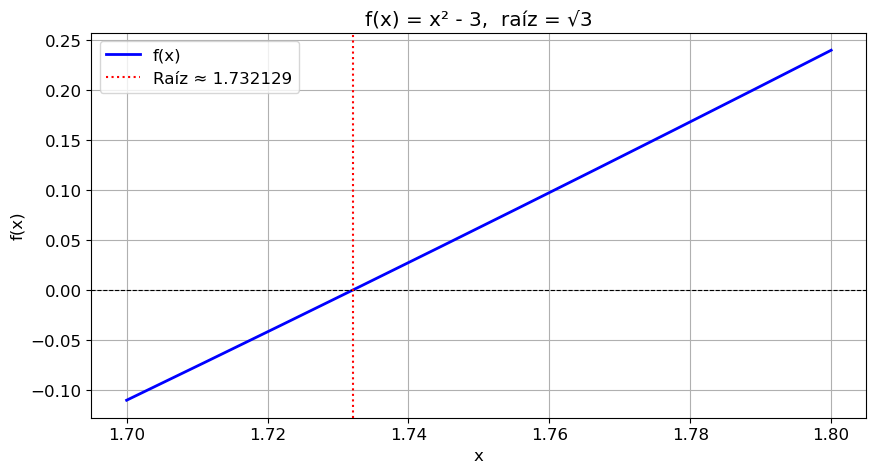

Iteraciones teóricas mínimas: 10
Iteraciones reales: 10

RESUMEN COMPARATIVO
Ejercicio    Raíz exacta     Raíz propia     Raíz scipy      Iteraciones  Tiempo propio (µs) Tiempo scipy (µs) 
----------------------------------------------------------------------------------------------------
13 (∛25)     2.9240177382    2.9239257812    2.9239257812    10           20.27              38.28             
14 (√3)      1.7320508076    1.7321289063    1.7321289063    10           19.41              26.45             


In [10]:
# Celda 1: Importaciones y función auxiliar (con retorno de tiempos)
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

def resolver_raiz(titulo, f, a, b, xtol=1e-4, exacta=None):
    """
    Resuelve f(x)=0 en [a,b] con bisección, compara con scipy, grafica.
    Retorna: (raiz_propia, raiz_scipy, historial, tiempo_propio, tiempo_scipy)
    """
    print(f"\n{titulo}")
    print(f"Intervalo: [{a}, {b}], tolerancia = {xtol:.0e}")
    
    # Nuestra implementación
    start = time.perf_counter()
    raiz_propia, hist, razon = biseccion(f, a, b, tol_abs=xtol, verbose=False)
    end = time.perf_counter()
    t_propio = end - start
    
    # Scipy
    start = time.perf_counter()
    raiz_scipy = sp_bisect(f, a, b, xtol=xtol)
    end = time.perf_counter()
    t_scipy = end - start
    
    print(f"Nuestra bisección: raíz = {raiz_propia:.10f}, iteraciones = {len(hist)}")
    print(f"  Tiempo: {t_propio:.6f} s, razón: {razon}")
    print(f"Scipy: raíz = {raiz_scipy:.10f}, tiempo: {t_scipy:.6f} s")
    print(f"Diferencia: {abs(raiz_propia - raiz_scipy):.2e}")
    if exacta is not None:
        error_propio = abs(raiz_propia - exacta)
        error_scipy = abs(raiz_scipy - exacta)
        print(f"Error real (respecto a {exacta:.10f}): propio = {error_propio:.2e}, scipy = {error_scipy:.2e}")
    
    # Gráfica
    x_plot = np.linspace(a, b, 500)
    y_plot = f(x_plot)
    plt.figure()
    plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
    plt.axvline(raiz_propia, color='r', linestyle=':', label=f'Raíz ≈ {raiz_propia:.6f}')
    plt.title(titulo)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return raiz_propia, raiz_scipy, hist, t_propio, t_scipy
# Celda 2: Ejercicio 13 - raíz cúbica de 25
print("="*80)
print("EJERCICIO 13: Aproximación de ∛25")
print("="*80)

def f13(x):
    return x**3 - 25

a13, b13 = 2.9, 3.0
exacta_13 = 25**(1/3)   # ≈ 2.924017738212866

raiz13, raiz13_s, hist13, t13_propio, t13_scipy = resolver_raiz(
    "f(x) = x³ - 25,  raíz = ∛25",
    f13, a13, b13, xtol=1e-4, exacta=exacta_13
)

n_teorico13 = math.ceil(math.log2((b13 - a13) / 1e-4))
print(f"Iteraciones teóricas mínimas: {n_teorico13}")
print(f"Iteraciones reales: {len(hist13)}")
# Celda 3: Ejercicio 14 - raíz cuadrada de 3
print("\n" + "="*80)
print("EJERCICIO 14: Aproximación de √3")
print("="*80)

def f14(x):
    return x**2 - 3

a14, b14 = 1.7, 1.8
exacta_14 = math.sqrt(3)   # ≈ 1.7320508075688772

raiz14, raiz14_s, hist14, t14_propio, t14_scipy = resolver_raiz(
    "f(x) = x² - 3,  raíz = √3",
    f14, a14, b14, xtol=1e-4, exacta=exacta_14
)

n_teorico14 = math.ceil(math.log2((b14 - a14) / 1e-4))
print(f"Iteraciones teóricas mínimas: {n_teorico14}")
print(f"Iteraciones reales: {len(hist14)}")
# Celda 4: Tabla comparativa de resultados (ahora con variables definidas)
print("\n" + "="*80)
print("RESUMEN COMPARATIVO")
print("="*80)

print(f"{'Ejercicio':<12} {'Raíz exacta':<15} {'Raíz propia':<15} {'Raíz scipy':<15} {'Iteraciones':<12} {'Tiempo propio (µs)':<18} {'Tiempo scipy (µs)':<18}")
print("-"*100)

# Usamos las variables correctamente definidas
for ex, raiz_ex, raiz_p, raiz_s, hist, t_p, t_s in [
    ("13 (∛25)", exacta_13, raiz13, raiz13_s, len(hist13), t13_propio*1e6, t13_scipy*1e6),
    ("14 (√3)",  exacta_14, raiz14, raiz14_s, len(hist14), t14_propio*1e6, t14_scipy*1e6)
]:
    print(f"{ex:<12} {raiz_ex:<15.10f} {raiz_p:<15.10f} {raiz_s:<15.10f} {hist:<12} {t_p:<18.2f} {t_s:<18.2f}")

Longitud L = 3.0480 m
Radio r = 0.3048 m
Volumen V = 0.351129 m³
F(0.0000) = 0.351129  (volumen teórico = 0.000000)
F(0.6096) = -0.538471  (volumen teórico = 0.889600)
Iter   1: a=0.0000000000, b=0.6096000000, p=0.3048000000, f(p)=-9.37e-02
Iter   2: a=0.0000000000, b=0.3048000000, p=0.1524000000, f(p)=1.77e-01
Iter   3: a=0.1524000000, b=0.3048000000, p=0.2286000000, f(p)=4.64e-02
Iter   4: a=0.2286000000, b=0.3048000000, p=0.2667000000, f(p)=-2.31e-02
Iter   5: a=0.2286000000, b=0.2667000000, p=0.2476500000, f(p)=1.19e-02
Iter   6: a=0.2476500000, b=0.2667000000, p=0.2571750000, f(p)=-5.54e-03
Iter   7: a=0.2476500000, b=0.2571750000, p=0.2524125000, f(p)=3.19e-03
Iter   8: a=0.2524125000, b=0.2571750000, p=0.2547937500, f(p)=-1.17e-03
  → Error absoluto 2.38e-03 < 3.05e-03

Profundidad h desde la parte superior: 0.2548 m
Razón: Error absoluto 2.38e-03 < 3.05e-03
Scipy: h = 0.2548 m


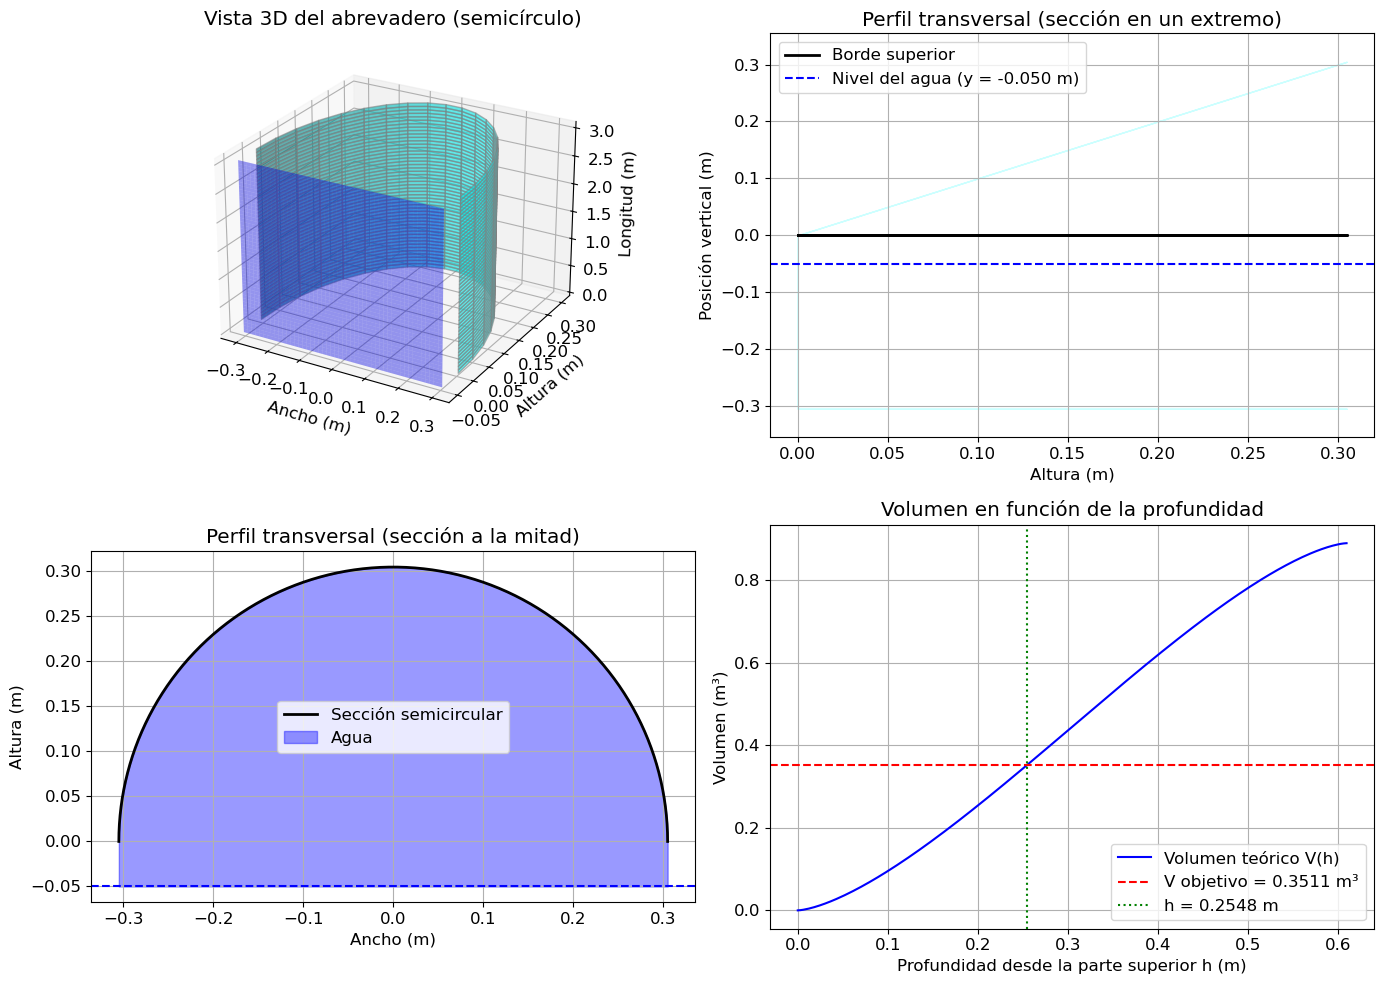


Profundidad desde la parte superior: h = 0.2548 m
Profundidad desde el fondo: 0.3548 m
Volumen calculado con h encontrada: 0.352304 m³
Volumen objetivo: 0.351129 m³
Diferencia: 1.17e-03 m³

En centímetros:
  h = 25.5 cm (desde el borde superior)
  Profundidad desde el fondo = 35.5 cm

Nuestra bisección: h = 0.2548 m, tiempo = 70.84 µs
Scipy: h = 0.2548 m, tiempo = 69.71 µs
Diferencia: 0.00e+00 m


In [11]:
#Ejercicio 15
#Cálculos previos y definición de la función
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion

# Conversión de unidades
pie_a_m = 0.3048
L_pies = 10.0
r_pies = 1.0
V_pies3 = 12.4

L = L_pies * pie_a_m          # 3.048 m
r = r_pies * pie_a_m          # 0.3048 m
V = V_pies3 * (pie_a_m)**3    # ≈ 0.3511289 m³

print(f"Longitud L = {L:.4f} m")
print(f"Radio r = {r:.4f} m")
print(f"Volumen V = {V:.6f} m³")

def volumen_teorico(h, L, r):
    """
    Volumen de agua en el abrevadero cuando la distancia desde la parte superior es h.
    h en metros, L y r en metros.
    """
    if h < 0 or h > 2*r:
        raise ValueError("h debe estar entre 0 y 2r")
    term1 = math.pi * r**2 / 2
    # Evitar problemas numéricos en arcsin cuando h está muy cerca de 0 o 2r
    arg = 1 - h/r
    if arg > 1:
        arg = 1.0
    elif arg < -1:
        arg = -1.0
    term2 = r**2 * math.asin(arg)
    term3 = (r - h) * math.sqrt(2*r*h - h**2) if h > 0 else 0
    return L * (term1 - term2 - term3)

def F(h):
    """Función residual: V - volumen_teorico(h)"""
    return V - volumen_teorico(h, L, r)
#2. Verificación del intervalo y aplicación de la bisección
a, b = 0.0, 2*r   # [0, 0.6096] m
fa, fb = F(a), F(b)
print(f"F({a:.4f}) = {fa:.6f}  (volumen teórico = {volumen_teorico(a, L, r):.6f})")
print(f"F({b:.4f}) = {fb:.6f}  (volumen teórico = {volumen_teorico(b, L, r):.6f})")

# Nuestra bisección
raiz_h, hist, razon = biseccion(F, a, b, tol_abs=0.01*pie_a_m, verbose=True)
print(f"\nProfundidad h desde la parte superior: {raiz_h:.4f} m")
print(f"Razón: {razon}")

# Scipy
raiz_h_sp = sp_bisect(F, a, b, xtol=0.01*pie_a_m)
print(f"Scipy: h = {raiz_h_sp:.4f} m")
#3. Visualización 3D del abrevadero y vistas de perfil
# Generar coordenadas para el sólido (abrevadero semicircular)
def generar_abrevadero(L, r, n_long=50, n_rad=20):
    """Genera puntos (x, y, z) para un abrevadero semicircular."""
    theta = np.linspace(-np.pi/2, np.pi/2, n_rad)   # ángulo desde -90° a 90°
    z = np.linspace(0, L, n_long)                  # eje longitudinal
    T, Z = np.meshgrid(theta, z)
    Y = r * np.cos(T)   # coordenada vertical (eje y hacia arriba)
    X = r * np.sin(T)   # coordenada horizontal
    return X, Y, Z

# Crear figura con subplots
fig = plt.figure(figsize=(14, 10))

# Subplot 1: Vista 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
X, Y, Z = generar_abrevadero(L, r)
ax1.plot_surface(X, Y, Z, alpha=0.6, color='cyan', edgecolor='gray')
# Marcar la superficie del agua (plano horizontal a y = - (r - h))
y_water = - (r - raiz_h)   # profundidad desde el borde superior
# Crear un plano de agua (limitado al ancho del abrevadero)
xx = np.linspace(-r, r, 50)
zz = np.linspace(0, L, 50)
XX, ZZ = np.meshgrid(xx, zz)
YY = np.full_like(XX, y_water)
ax1.plot_surface(XX, YY, ZZ, alpha=0.4, color='blue', label='Agua')
ax1.set_title('Vista 3D del abrevadero (semicírculo)')
ax1.set_xlabel('Ancho (m)')
ax1.set_ylabel('Altura (m)')
ax1.set_zlabel('Longitud (m)')
ax1.view_init(elev=25, azim=-60)

# Subplot 2: Perfil longitudinal (corte por el eje central)
ax2 = fig.add_subplot(2, 2, 2)
# Sección longitudinal: x=0, y = r*cos(theta) -> en el centro x=0, y varía
theta_long = np.linspace(-np.pi/2, np.pi/2, 100)
y_long = r * np.cos(theta_long)
z_long = np.linspace(0, L, 100)
# Para el perfil, mostramos y vs z (altura a lo largo del canal)
# Dibujar el borde semicircular en un extremo (z=0)
ax2.plot(y_long, np.zeros_like(y_long), 'k-', linewidth=2, label='Borde superior')
ax2.fill_between(y_long, -r, y_long, alpha=0.2, color='cyan')
ax2.axhline(y_water, color='blue', linestyle='--', label=f'Nivel del agua (y = {y_water:.3f} m)')
ax2.set_title('Perfil transversal (sección en un extremo)')
ax2.set_xlabel('Altura (m)')
ax2.set_ylabel('Posición vertical (m)')
ax2.set_ylim(-r-0.05, r+0.05)
ax2.grid(True)
ax2.legend()

# Subplot 3: Perfil transversal (vista desde el extremo)
ax3 = fig.add_subplot(2, 2, 3)
# Sección transversal en z=L/2 (mitad del canal)
theta = np.linspace(-np.pi/2, np.pi/2, 100)
x_t = r * np.sin(theta)
y_t = r * np.cos(theta)
ax3.plot(x_t, y_t, 'k-', linewidth=2, label='Sección semicircular')
# Agua: hasta y = y_water
mask = y_t >= y_water
ax3.fill_between(x_t[mask], y_t[mask], y_water, alpha=0.4, color='blue', label='Agua')
ax3.axhline(y_water, color='blue', linestyle='--')
ax3.set_title('Perfil transversal (sección a la mitad)')
ax3.set_xlabel('Ancho (m)')
ax3.set_ylabel('Altura (m)')
ax3.set_aspect('equal')
ax3.grid(True)
ax3.legend()

# Subplot 4: Evolución del volumen con la profundidad (gráfica de F(h))
ax4 = fig.add_subplot(2, 2, 4)
h_vals = np.linspace(0, 2*r, 200)
vol_vals = [volumen_teorico(h, L, r) for h in h_vals]
ax4.plot(h_vals, vol_vals, 'b-', label='Volumen teórico V(h)')
ax4.axhline(V, color='r', linestyle='--', label=f'V objetivo = {V:.4f} m³')
ax4.axvline(raiz_h, color='g', linestyle=':', label=f'h = {raiz_h:.4f} m')
ax4.set_xlabel('Profundidad desde la parte superior h (m)')
ax4.set_ylabel('Volumen (m³)')
ax4.set_title('Volumen en función de la profundidad')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()
#4. Resultados numéricos y conversión a unidades prácticas
# Resultados en metros
print(f"\nProfundidad desde la parte superior: h = {raiz_h:.4f} m")
profundidad_fondo = 2*r - raiz_h
print(f"Profundidad desde el fondo: {profundidad_fondo:.4f} m")
print(f"Volumen calculado con h encontrada: {volumen_teorico(raiz_h, L, r):.6f} m³")
print(f"Volumen objetivo: {V:.6f} m³")
print(f"Diferencia: {abs(volumen_teorico(raiz_h, L, r) - V):.2e} m³")

# Conversión a centímetros (para mayor claridad)
print(f"\nEn centímetros:")
print(f"  h = {raiz_h*100:.1f} cm (desde el borde superior)")
print(f"  Profundidad desde el fondo = {profundidad_fondo*100:.1f} cm")
#5. Comparación con scipy (tiempos y precisión)
import time
from scipy.optimize import bisect as sp_bisect

# Medir tiempos (una sola ejecución, pero podemos hacer 1000 repeticiones)
start = time.perf_counter()
raiz_h, _, _ = biseccion(F, a, b, tol_abs=0.01*pie_a_m, verbose=False)
t_propio = time.perf_counter() - start

start = time.perf_counter()
raiz_sp = sp_bisect(F, a, b, xtol=0.01*pie_a_m)
t_scipy = time.perf_counter() - start

print(f"\nNuestra bisección: h = {raiz_h:.4f} m, tiempo = {t_propio*1e6:.2f} µs")
print(f"Scipy: h = {raiz_sp:.4f} m, tiempo = {t_scipy*1e6:.2f} µs")
print(f"Diferencia: {abs(raiz_h - raiz_sp):.2e} m")

Bisección converge a: 0.5000000000
f(raiz) = 0.0
Razón: |f(p)| = 0.00e+00 < 1.00e-15


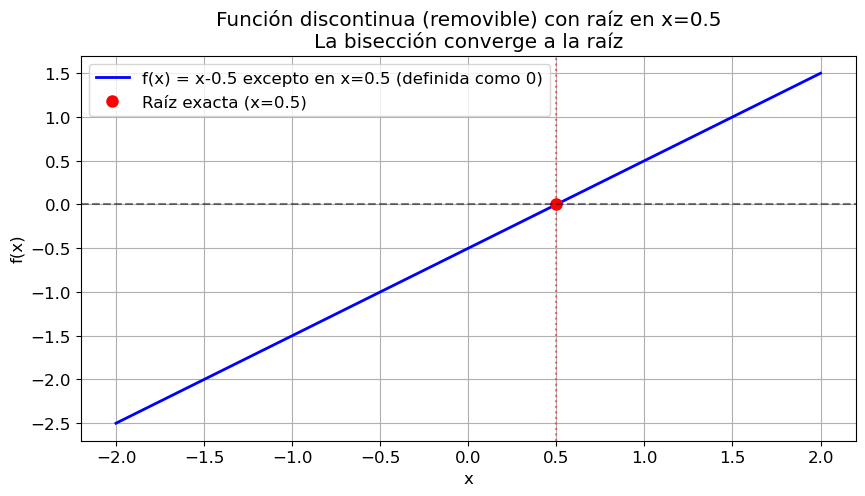

In [13]:
def f_discontinua_raiz(x):
    if x == 0.5:
        return 0.0
    else:
        return x - 0.5

# Aplicar bisección
a, b = 0.0, 1.0
raiz, hist, razon = biseccion(f_discontinua_raiz, a, b, tol_abs=1e-10, verbose=False)
print(f"Bisección converge a: {raiz:.10f}")
print(f"f(raiz) = {f_discontinua_raiz(raiz)}")
print(f"Razón: {razon}")

# Gráfica
x = np.linspace(-2, 2, 1000)
y = np.array([f_discontinua_raiz(xi) for xi in x])
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b-', linewidth=2, label='f(x) = x-0.5 excepto en x=0.5 (definida como 0)')
plt.plot(0.5, 0, 'ro', markersize=8, label='Raíz exacta (x=0.5)')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='r', linestyle=':', alpha=0.5)
plt.title('Función discontinua (removible) con raíz en x=0.5\nLa bisección converge a la raíz')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()